# Machine Learning Model Training

### Load dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_dataset.csv to cleaned_dataset (3).csv


In [2]:
import pandas as pd

df = pd.read_csv("cleaned_dataset.csv")
df.head()

,T_feed,P_feed,z_benzene,reflux_ratio,stages,feed_stage,bottoms_flow,xD,xB,QC,QR
0,121.863389,1.165677,0.257171,4.146966,13.0,4.0,50.408283,0.732362,0.015341,363.691448,-373.005068
1,89.459707,1.638306,0.364948,4.224859,27.0,3.0,52.202497,0.763635,0.017705,508.301600,-306.094604
2,115.172163,1.843883,0.626730,4.901157,29.0,18.0,46.260664,0.987195,0.126703,636.041981,-250.296414
3,101.483985,1.810678,0.452148,3.934965,18.0,9.0,77.320856,0.782563,0.019401,626.130267,-251.510105
4,120.572133,1.436241,0.608326,3.059427,21.0,10.0,59.541746,0.978757,0.095971,634.435014,-250.295981


# xD

### Define inputs and outputs

In [3]:
X = df[[
    "T_feed",
    "P_feed",
    "z_benzene",
    "reflux_ratio",
    "stages",
    "feed_stage",
    "bottoms_flow"
]]

y_xD = df["xD"]
y_xB = df["xB"]
y_QC = df["QC"]
y_QR = df["QR"]

### Train-test split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_xD, test_size=0.2, random_state=42
)

### Model 1 : Polynomial Regression

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

poly_model.fit(X_train, y_train)

y_pred_poly = poly_model.predict(X_test)

### Model 2: Random Forest

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

### Model 3: XGBoost

In [7]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, random_state=42)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

### Model 4: ANN

In [8]:
from sklearn.neural_network import MLPRegressor

ann_model = MLPRegressor(hidden_layer_sizes=(50,50), max_iter=1000, random_state=42)

ann_model.fit(X_train, y_train)

y_pred_ann = ann_model.predict(X_test)

### Model Evaluation

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [10]:
models = {
    "Polynomial": y_pred_poly,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,

}

for name, pred in models.items():
    mae, rmse, r2 = evaluate(y_test, pred)
    print(f"{name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

Polynomial: MAE=0.0261, RMSE=0.0309, R2=0.9329
Random Forest: MAE=0.0008, RMSE=0.0020, R2=0.9997
XGBoost: MAE=0.0015, RMSE=0.0026, R2=0.9995


### Plot prediction

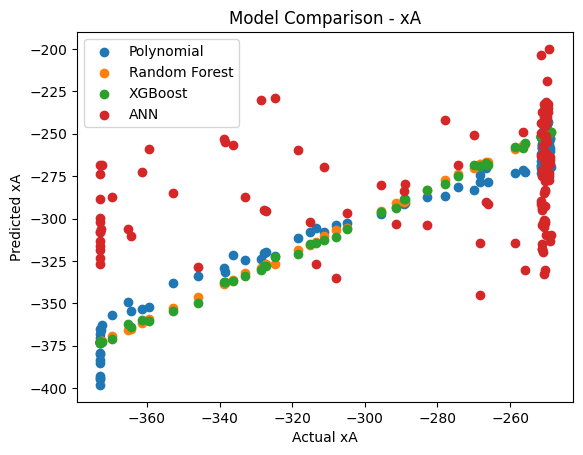

In [27]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, y_pred_poly, label="Polynomial")
plt.scatter(y_test, y_pred_rf, label="Random Forest")
plt.scatter(y_test, y_pred_xgb, label="XGBoost")
plt.scatter(y_test, y_pred_ann, label="ANN")

plt.legend()
plt.xlabel("Actual xA")
plt.ylabel("Predicted xA")
plt.title("Model Comparison - xA")

plt.show()

#xB

In [12]:
y = df["xB"]

### Train-test split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train ALL the models

In [14]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

# Polynomial
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])
poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# XGBoost
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# ANN
ann_model = MLPRegressor(hidden_layer_sizes=(64,64), max_iter=500)
ann_model.fit(X_train, y_train)
y_pred_ann = ann_model.predict(X_test)

### Model Evaluation

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

models = {
    "Polynomial": y_pred_poly,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "ANN": y_pred_ann
}

for name, pred in models.items():
    mae, rmse, r2 = evaluate(y_test, pred)
    print(f"{name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

Polynomial: MAE=0.0228, RMSE=0.0285, R2=0.9541
Random Forest: MAE=0.0007, RMSE=0.0014, R2=0.9999
XGBoost: MAE=0.0016, RMSE=0.0032, R2=0.9994
ANN: MAE=0.0852, RMSE=0.1102, R2=0.3126


### Plot prediction

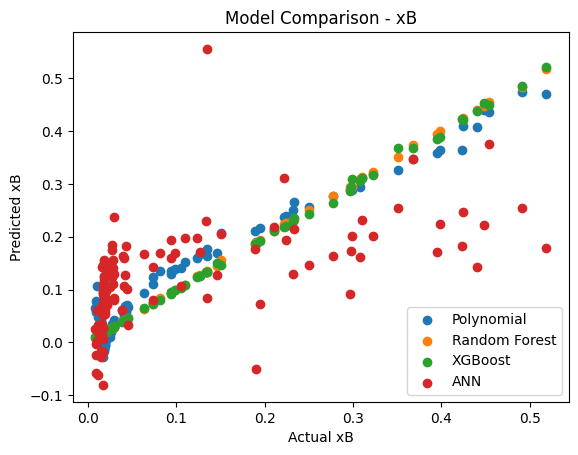

In [16]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, y_pred_poly, label="Polynomial")
plt.scatter(y_test, y_pred_rf, label="Random Forest")
plt.scatter(y_test, y_pred_xgb, label="XGBoost")
plt.scatter(y_test, y_pred_ann, label="ANN")

plt.xlabel("Actual xB")
plt.ylabel("Predicted xB")
plt.title("Model Comparison - xB")
plt.legend()

plt.show()

# QC


In [17]:
y = df["QC"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

# Polynomial
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])
poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# XGBoost
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# ANN
ann_model = MLPRegressor(hidden_layer_sizes=(64,64), max_iter=500)
ann_model.fit(X_train, y_train)
y_pred_ann = ann_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

models = {
    "Polynomial": y_pred_poly,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "ANN": y_pred_ann
}

for name, pred in models.items():
    mae, rmse, r2 = evaluate(y_test, pred)
    print(f"{name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

Polynomial: MAE=17.2159, RMSE=20.5383, R2=0.9605
Random Forest: MAE=0.4110, RMSE=0.8415, R2=0.9999
XGBoost: MAE=0.8347, RMSE=1.5215, R2=0.9998
ANN: MAE=77.3980, RMSE=96.2468, R2=0.1329


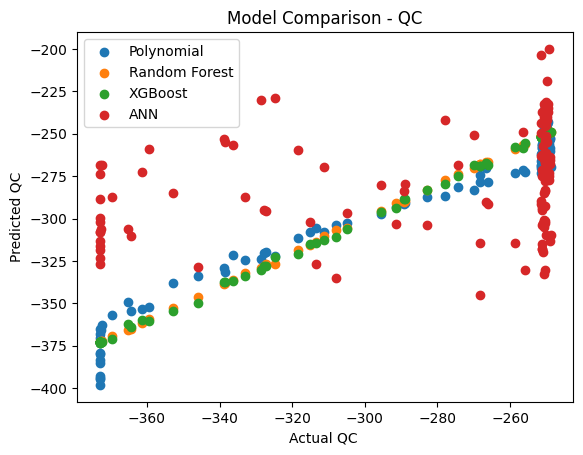

In [29]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, y_pred_poly, label="Polynomial")
plt.scatter(y_test, y_pred_rf, label="Random Forest")
plt.scatter(y_test, y_pred_xgb, label="XGBoost")
plt.scatter(y_test, y_pred_ann, label="ANN")

plt.xlabel("Actual QC ")
plt.ylabel("Predicted QC")
plt.title("Model Comparison - QC")
plt.legend()

plt.show()

#QR

In [22]:
y = df["QR"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

# Polynomial
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])
poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_test)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# XGBoost
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# ANN
ann_model = MLPRegressor(hidden_layer_sizes=(64,64), max_iter=500)
ann_model.fit(X_train, y_train)
y_pred_ann = ann_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

models = {
    "Polynomial": y_pred_poly,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "ANN": y_pred_ann
}

for name, pred in models.items():
    mae, rmse, r2 = evaluate(y_test, pred)
    print(f"{name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

Polynomial: MAE=8.2216, RMSE=9.8215, R2=0.9551
Random Forest: MAE=0.1450, RMSE=0.3342, R2=0.9999
XGBoost: MAE=0.4542, RMSE=0.8805, R2=0.9996
ANN: MAE=38.2831, RMSE=47.4197, R2=-0.0478


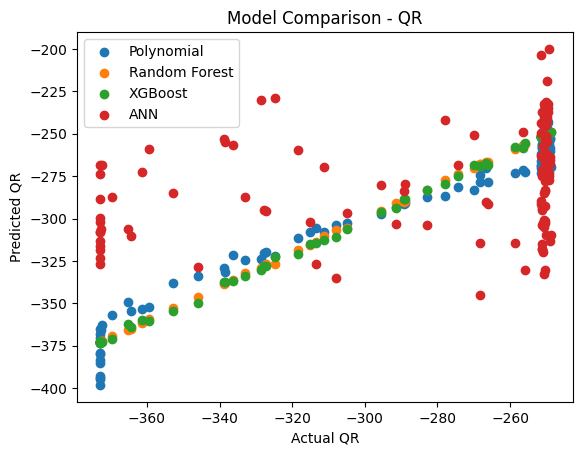

In [28]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, y_pred_poly, label="Polynomial")
plt.scatter(y_test, y_pred_rf, label="Random Forest")
plt.scatter(y_test, y_pred_xgb, label="XGBoost")
plt.scatter(y_test, y_pred_ann, label="ANN")

plt.xlabel("Actual QR")
plt.ylabel("Predicted QR")
plt.title("Model Comparison - QR")
plt.legend()

plt.show()